Carga

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = "workload_clean.csv"

df = pd.read_csv(file_path)

print("Dataset cargado correctamente.")
print(f"Registros: {len(df):,}")
print(f"Columnas: {len(df.columns)}")

Dataset cargado correctamente.
Registros: 2,695,548
Columnas: 12


info general

In [2]:

print(f"Total de registros: {len(df):,}")
print(f"Subscriptions únicas: {df['subscriptionid'].nunique():,}")
print(f"Deployments únicos: {df['deploymentid'].nunique():,}")

print("\nValores nulos:")
print(df[['subscriptionid', 'deploymentid']].isnull().sum())

Total de registros: 2,695,548
Subscriptions únicas: 6,687
Deployments únicos: 33,205

Valores nulos:
subscriptionid    0
deploymentid      0
dtype: int64


Frecuencia de suscripciones

In [3]:
subscription_frequency = (
    df['subscriptionid']
    .value_counts(dropna=False)
    .rename_axis('subscriptionid')
    .reset_index(name='num_records')
)

print(subscription_frequency.head(20))

   subscriptionid  num_records
0           SUB10       366225
1           SUB27        87230
2           SUB21        49547
3           SUB24        48524
4           SUB73        47057
5           SUB31        41690
6            SUB7        38619
7           SUB92        37810
8          SUB113        34023
9           SUB14        34022
10          SUB32        30118
11          SUB38        28473
12         SUB241        28451
13          SUB15        27982
14          SUB78        27978
15           SUB8        27953
16         SUB146        27942
17           SUB6        27942
18          SUB62        27898
19          SUB58        27885


frecuencia de deployments

In [5]:
deployment_frequency = (
    df['deploymentid']
    .value_counts(dropna=False)
    .rename_axis('deploymentid')
    .reset_index(name='num_records')
)

print(deployment_frequency.head(20))

   deploymentid  num_records
0        DEP236        19113
1         DEP14        18732
2        DEP267        17066
3        DEP179        16529
4         DEP83        16001
5         DEP42        15052
6         DEP11        14693
7         DEP64        14284
8        DEP489        14268
9         DEP21        14239
10        DEP28        14012
11       DEP576        13824
12       DEP177        13808
13       DEP393        13199
14       DEP118        13121
15        DEP98        12992
16       DEP221        11952
17       DEP143        11666
18       DEP313        11624
19        DEP33        11561


Deployments por suscripcion

In [6]:
subscription_deployments = (
    df.groupby('subscriptionid')['deploymentid']
      .nunique()
      .reset_index(name='num_deployments')
      .sort_values('num_deployments', ascending=False)
)

print(subscription_deployments.head(20))

     subscriptionid  num_deployments
3334           SUB4               62
6599          SUB92               60
447          SUB140               52
6410          SUB75               51
6333         SUB680               43
6621          SUB94               40
6001          SUB64               36
2502         SUB325               34
25           SUB102               34
6558         SUB883               33
6574         SUB898               32
6335         SUB682               32
1079         SUB197               32
6373         SUB716               32
240         SUB1213               32
5512         SUB596               32
1136         SUB202               31
1147         SUB203               31
3101         SUB379               31
3046         SUB374               31


Suscripciones por deployment

In [7]:

deployment_subscriptions = (
    df.groupby('deploymentid')['subscriptionid']
      .nunique()
      .reset_index(name='num_subscriptions')
      .sort_values('num_subscriptions', ascending=False)
)

print(deployment_subscriptions.head(20))


      deploymentid  num_subscriptions
33204      DEP9999                  1
0             DEP0                  1
1             DEP1                  1
2            DEP10                  1
3           DEP100                  1
33188      DEP9984                  1
33187      DEP9983                  1
33186      DEP9982                  1
33185      DEP9981                  1
33184      DEP9980                  1
33183       DEP998                  1
33182      DEP9979                  1
33181      DEP9978                  1
33180      DEP9977                  1
33179      DEP9976                  1
33178      DEP9975                  1
33177      DEP9974                  1
33176      DEP9973                  1
33175      DEP9972                  1
33174      DEP9971                  1


Relacion suscripcion -deployment

In [8]:
relationship = (
    df.groupby(
        ['subscriptionid', 'deploymentid']
    )
    .size()
    .reset_index(name='num_records')
    .sort_values('num_records', ascending=False)
)

print(relationship.head(30))

     subscriptionid deploymentid  num_records
3363         SUB129       DEP236        19113
52            SUB10        DEP14        18732
62            SUB10       DEP267        17066
56            SUB10       DEP179        16529
77            SUB10        DEP83        16001
67            SUB10        DEP42        15052
49            SUB10        DEP11        14693
75            SUB10        DEP64        14284
70            SUB10       DEP489        14268
58            SUB10        DEP21        14239
63            SUB10        DEP28        14012
71            SUB10       DEP576        13824
55            SUB10       DEP177        13808
66            SUB10       DEP393        13199
50            SUB10       DEP118        13121
78            SUB10        DEP98        12992
59            SUB10       DEP221        11952
53            SUB10       DEP143        11666
64            SUB10       DEP313        11624
65            SUB10        DEP33        11561
68            SUB10       DEP424  

Estadisticas: deployments por suscripcion

In [9]:
print(
    subscription_deployments['num_deployments']
    .describe()
)

count    6687.000000
mean        4.965605
std         8.148286
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max        62.000000
Name: num_deployments, dtype: float64


Estadisticas: Suscripciones por deployment

In [10]:
print(
    deployment_subscriptions['num_subscriptions']
    .describe()
)

count    33205.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: num_subscriptions, dtype: float64


11. DEPLOYMENTS QUE PERTENECEN A MÁS DE UNA SUBSCRIPTION


In [12]:
multiple_subscription_deployments = (
    deployment_subscriptions[
        deployment_subscriptions['num_subscriptions'] > 1
    ]
)

print(
    "\nDeployments asociados a más de una subscription:"
)

print(len(multiple_subscription_deployments))

print(
    multiple_subscription_deployments.head(20)
)


Deployments asociados a más de una subscription:
0
Empty DataFrame
Columns: [deploymentid, num_subscriptions]
Index: []


Top 20 suscripciones por numero de registros

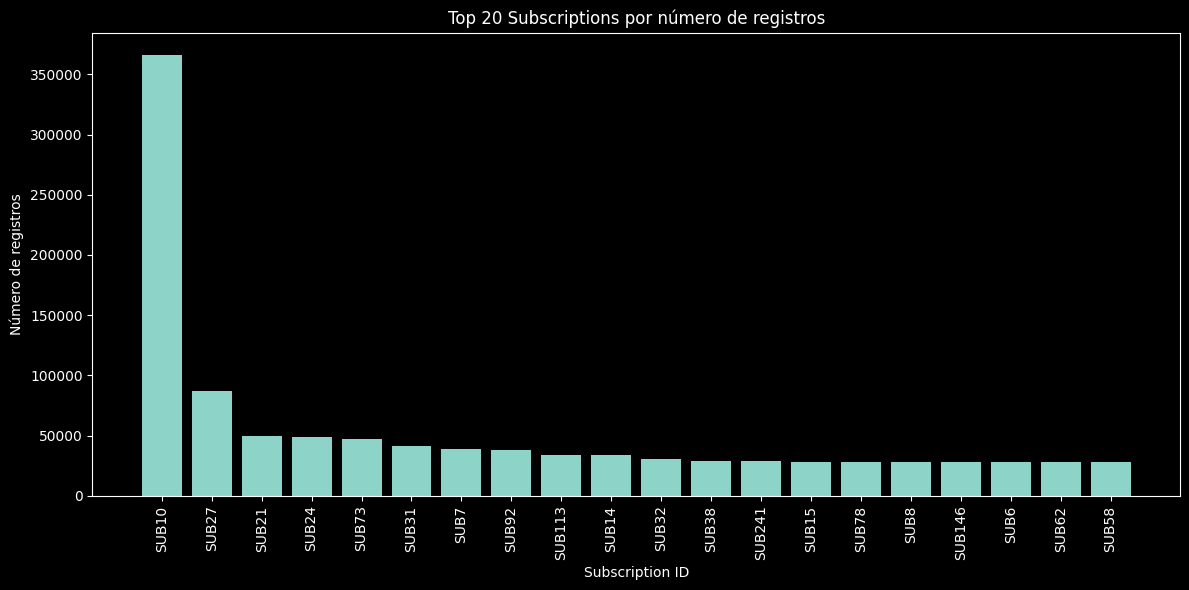

In [13]:
top_subscriptions = subscription_frequency.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top_subscriptions['subscriptionid'].astype(str),
    top_subscriptions['num_records']
)

plt.title(
    'Top 20 Subscriptions por número de registros'
)

plt.xlabel('Subscription ID')
plt.ylabel('Número de registros')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


Top 20 deployments por numero de registros

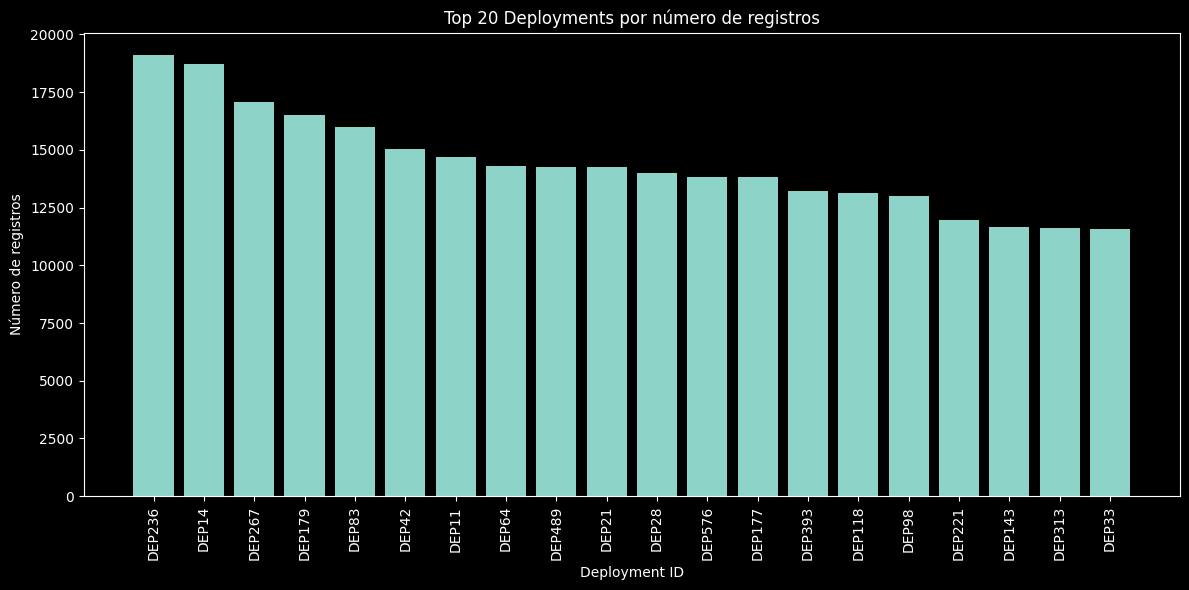

In [14]:
top_deployments = deployment_frequency.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top_deployments['deploymentid'].astype(str),
    top_deployments['num_records']
)

plt.title(
    'Top 20 Deployments por número de registros'
)

plt.xlabel('Deployment ID')
plt.ylabel('Número de registros')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

Distribucion de deployments por suscripcion

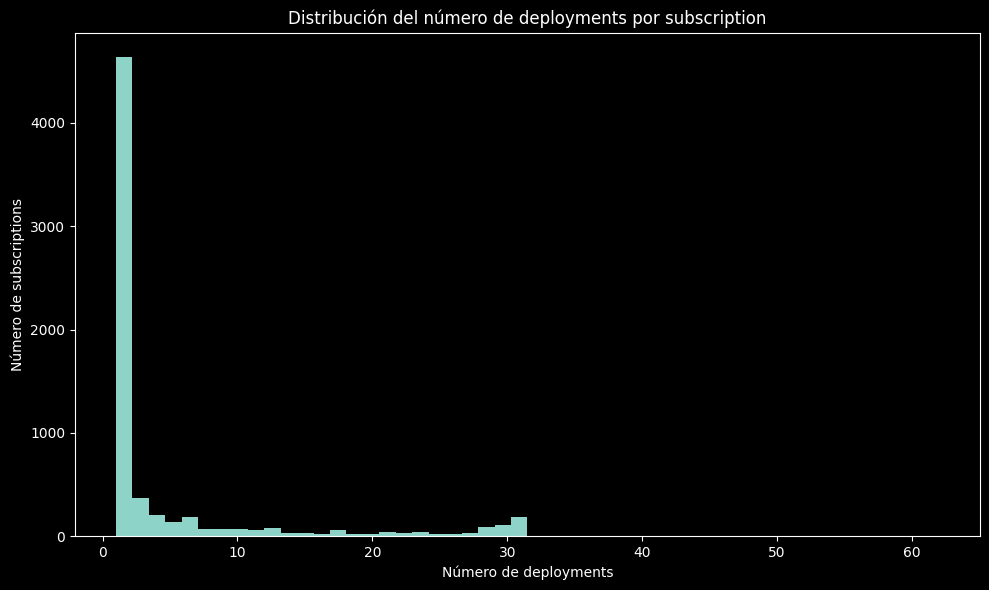

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    subscription_deployments['num_deployments'],
    bins=50
)

plt.title(
    'Distribución del número de deployments por subscription'
)

plt.xlabel('Número de deployments')
plt.ylabel('Número de subscriptions')

plt.tight_layout()

plt.show()


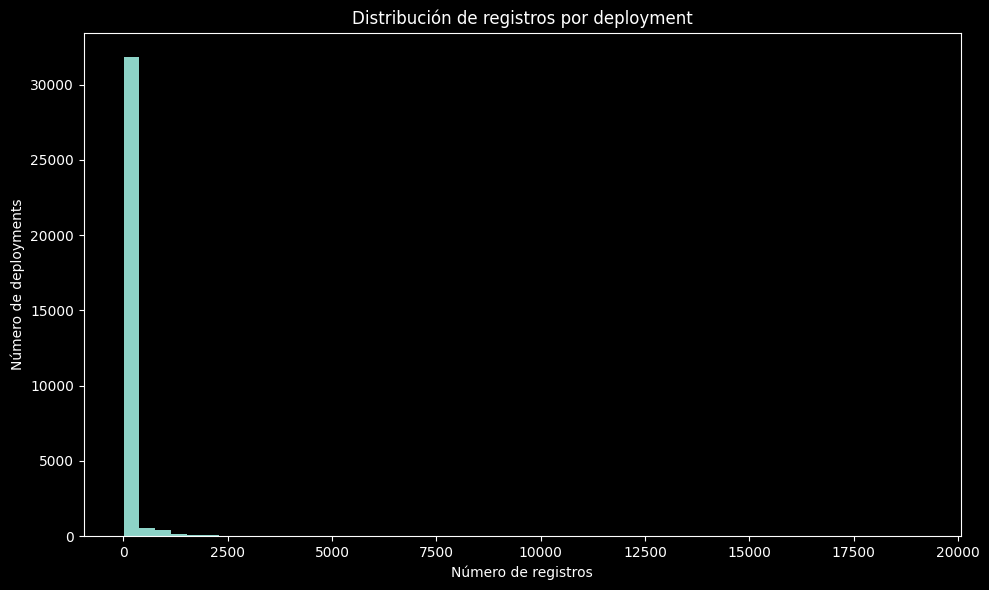

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    deployment_frequency['num_records'],
    bins=50
)

plt.title(
    'Distribución de registros por deployment'
)

plt.xlabel('Número de registros')
plt.ylabel('Número de deployments')

plt.tight_layout()

plt.show()